# Fine-Tune Pretrained Commutative CNN Classifier

Load the pretrained commutative CNN encoder and fine-tune the full network on the current labeled action dataset.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeCNNClassifier,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_chunked_water_vs_other_hot_start,
    fit_estimator_on_experiment,
    load_commutative_cnn_pretraining_config,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
    prepare_water_vs_other_pretraining_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import (
    build_tensor_embedding_2d,
    load_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


In [2]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
unlabeled_dataset_path = Path(".dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks")
pretraining_config_path = Path("artifacts/pretrained_commutative_cnn/config.yaml")
pretraining_config = load_commutative_cnn_pretraining_config(pretraining_config_path)
print(f"Loaded commutative CNN pretraining config from {pretraining_config_path}")
print(pretraining_config)

pretrained_encoder_path = pretraining_config.pretrained_encoder_path
if not pretrained_encoder_path.exists():
    raise FileNotFoundError(
        f"Pretrained CNN encoder not found at {pretrained_encoder_path}. "
        "Run 10C_pretrain_commutative_cnn_encoder.ipynb first, or update "
        "artifacts/pretrained_commutative_cnn/config.yaml to point at an existing checkpoint."
    )
model_config = pretraining_config.model_config
experiment_output_dir = Path("artifacts/nb13C_commutative_cnn_full_finetune")
binary_loss_plot_dir = experiment_output_dir / "loss_plots" / "binary_hot_start"
fine_tune_loss_plot_dir = experiment_output_dir / "loss_plots" / "fine_tune"
persist_artifacts = True
print(f"Using pretrained encoder checkpoint: {pretrained_encoder_path.resolve()}")
print(f"Binary hot-start loss PDFs: {binary_loss_plot_dir.resolve()}")
print(f"Fine-tune loss PDFs: {fine_tune_loss_plot_dir.resolve()}")

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 4
rotation_range_degrees = 10.0
run_binary_hot_start = True
binary_pretraining_epochs = 8
binary_learning_rate = 2e-5
binary_weight_decay = 5e-4
binary_class_weighting = "balanced"

optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=1e-5,
    weight_decay=7.5e-4,
    early_stopping_patience=12,
    early_stopping_min_delta=1e-4,
    early_stopping_start_epoch=15,
    early_stopping_monitor="action_loss",
    early_stopping_smoothing="median",
    early_stopping_smoothing_window=5,
    scheduler_patience=4,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    training_plot_dir=str(fine_tune_loss_plot_dir),
    training_plot_every_n_epochs=1,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
    class_weighting="balanced",
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    water_vs_other_weight=0.25,
    compound_weight=0.0,
    concentration_weight=0.0,
    latent_alignment_weight=0.0,
    lambda_align=0.0,
)


Loaded commutative CNN pretraining config from artifacts/pretrained_commutative_cnn/config.yaml
CommutativeCNNPretrainingConfig(unlabeled_dataset_path=PosixPath('.dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks'), pretrained_encoder_path=PosixPath('artifacts/pretrained_commutative_cnn/encoder_state_v8.pt'), validation_fraction=0.15, train_num_random_rotations=0, rotation_range_degrees=0.0, model_config=CommutativeCNNConfig(spatial_conv_channels=(16, 32), spatial_kernel_size_z=(3, 1), spatial_kernel_size_xy=(5, 3), spatial_stride_z=(1, 1), spatial_stride_xy=(1, 1), spatial_pool_kernel_z=(1, 1), spatial_pool_kernel_xy=(2, 2), spatial_pool_stride_z=(1, 1), spatial_pool_stride_xy=(2, 2), temporal_st_channels=(48, 64), temporal_st_kernel_sizes=(5, 3), temporal_ts_channels=(32, 48, 64), temporal_ts_kernel_sizes=(7, 5, 3), spatial_agg_channels=(32, 64), spatial_agg_kernel_size_z=(3, 1), spatial_agg_kernel_size_xy=(3, 3), spatial_agg_stride_z=(1, 1), spatial_agg_stride_xy=(1,

## Output Review

The latest binary hot-start run reached its best validation accuracy early, then drifted toward a water-heavy solution despite the restored checkpoint. The next run keeps the gentle `learning_rate=2e-5` but limits the hot-start to `8` epochs so the binary boundary helps initialization without dominating the multiclass action objective.

The v8 fine-tune had stable validation loss but weak holdout macro behavior: Water recall was high while AChE and mAChR recall were both zero. The next run prioritizes action macro behavior by using balanced multiclass action loss, reducing `water_vs_other_weight` to `0.25`, restoring stronger labeled rotation augmentation, lowering fine-tune `learning_rate` to `1e-5`, and raising `weight_decay` to `7.5e-4`. Exact latent alignment remains explicitly disabled with `latent_alignment_weight=0.0` / `lambda_align=0.0`.

In [3]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,336
1,train_base,168
2,val,42
3,holdout,71


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,14
1,GABAAR_Antagonist,Bemegride,control,14
2,AChE_Inhibitor_Reversible,Galantamine,high,12
3,GABAAR_Antagonist,Gabazine,control,12
4,mAChR_Agonist_NonSelective,Bethanechol,high,12
5,mAChR_Agonist_NonSelective,Bethanechol,mid,12
6,mAChR_Agonist_NonSelective,Muscarine,high,12
7,NMDAR_Activation,Cis-ACPD,control,12
8,mAChR_Agonist_NonSelective,Pilocarpine,high,10
9,mAChR_Agonist_NonSelective,Bethanechol,control,10


## Memory Note

The unlabeled pretraining chunks are large and `load_unlabeled_tensor_dataset(...)` concatenates them into one CPU tensor. This notebook keeps the intended water-vs-other hot-start, but runs it with `fit_chunked_water_vs_other_hot_start(...)`, which scans and trains from chunks instead of materializing the full unlabeled tensor in RAM. Supervised rotation augmentation is reduced because it materializes augmented labeled tensors in memory before fitting.

Writing binary hot-start loss PDFs to: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_full_finetune/loss_plots/binary_hot_start
Binary hot-start optimizer: lr=2e-05, weight_decay=0.0005, class_weighting=balanced
Commutative CNN model: parameters=182,668 trainable=182,668 size=0.70 MB
001/040 lr=2.00e-05 eta=8:49:04 train_loss=0.6886 val_loss=0.6809 train_acc=0.748 val_acc=0.757
002/040 lr=2.00e-05 eta=8:07:58 train_loss=0.6882 val_loss=0.6773 train_acc=0.748 val_acc=0.757
003/040 lr=2.00e-05 eta=7:39:45 train_loss=0.6855 val_loss=0.6731 train_acc=0.747 val_acc=0.757
004/040 lr=2.00e-05 eta=7:48:24 train_loss=0.6848 val_loss=0.6836 train_acc=0.726 val_acc=0.757
005/040 lr=2.00e-05 eta=7:42:54 train_loss=0.6837 val_loss=0.6726 train_acc=0.741 val_acc=0.757
006/040 lr=2.00e-05 eta=7:19:59 train_loss=0.6836 val_loss=0.6720 train_acc=0.726 val_acc=0.757
007/040 lr=2.00e-05 eta=6:53:10 train_loss=0.6811 val_loss=0.6688 tr

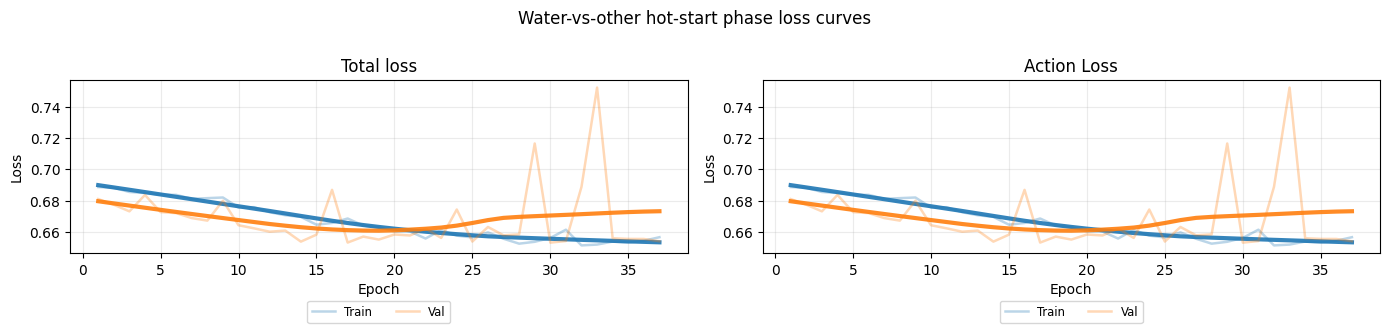

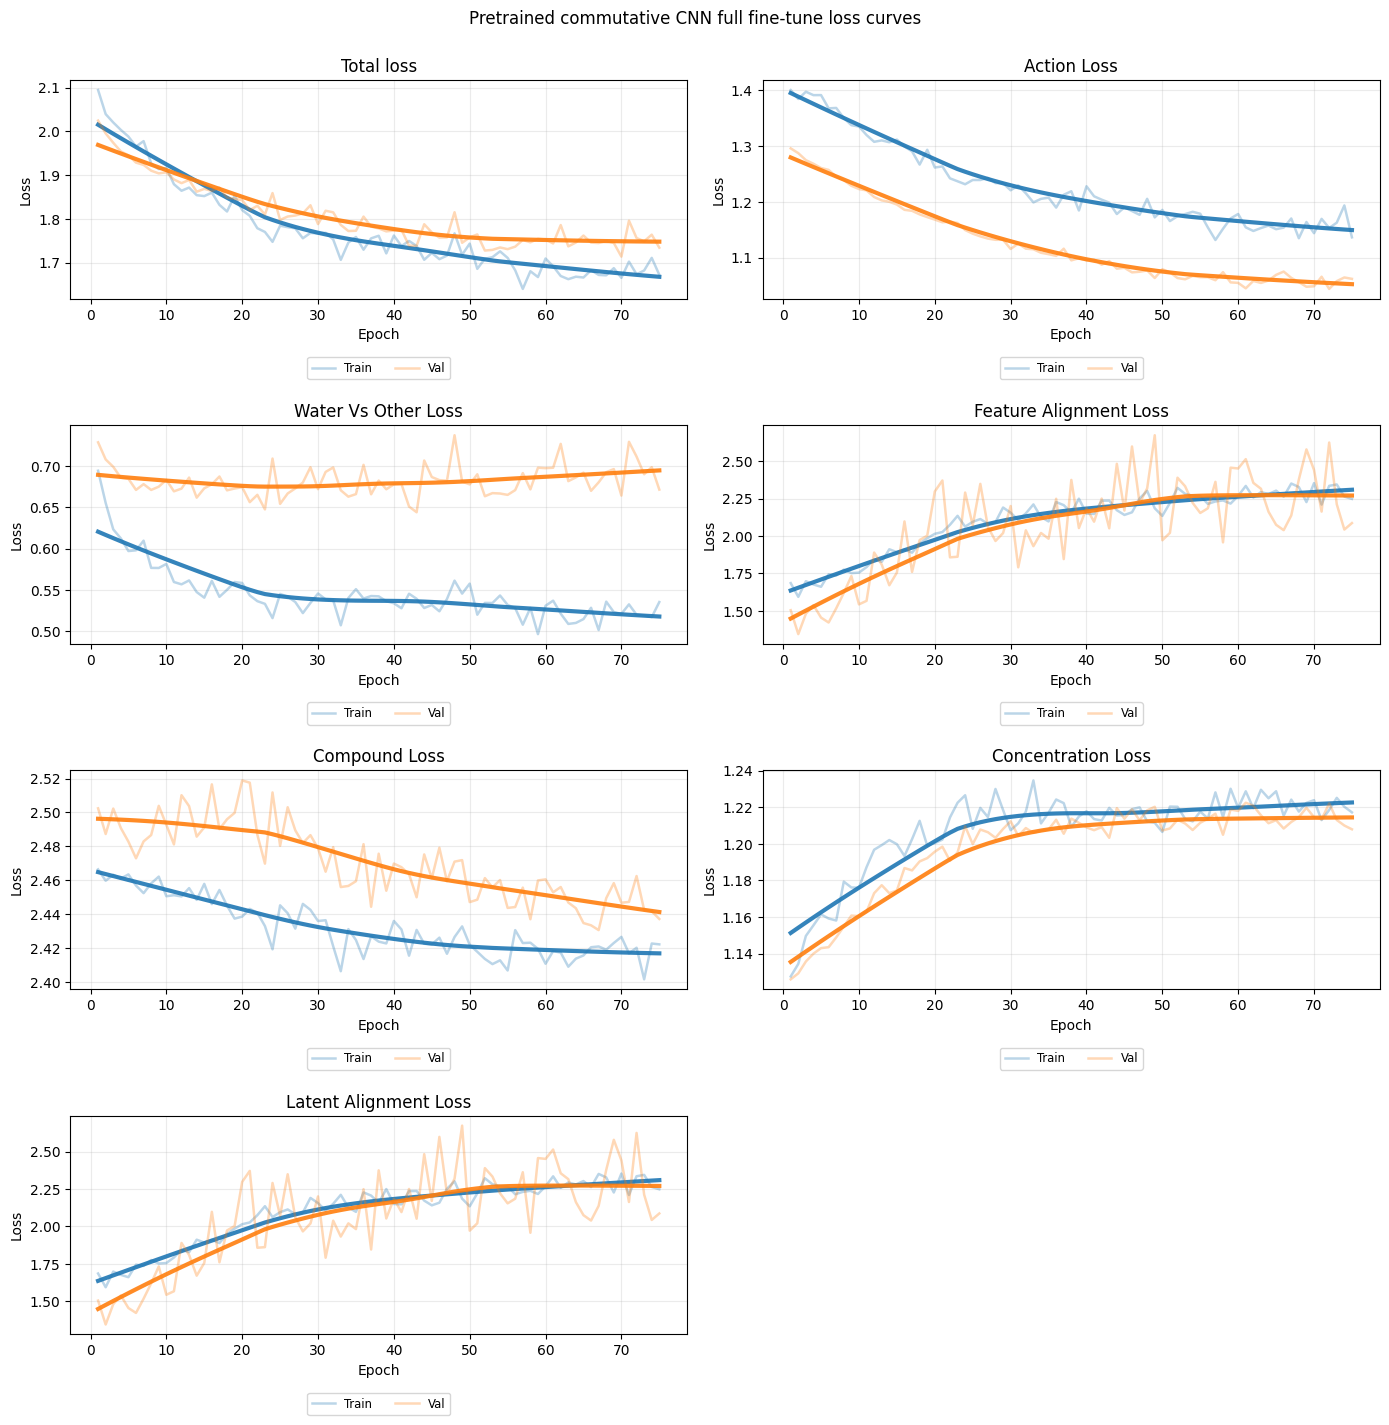

In [4]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=False,
    hot_start=True,
)

binary_pretraining_data = None
binary_pretraining_history = None
if run_binary_hot_start and binary_pretraining_epochs > 0:
    final_epochs = model.epochs
    final_learning_rate = model.learning_rate
    final_weight_decay = model.weight_decay
    model.training_plot_dir = str(binary_loss_plot_dir)
    model.training_plot_title = "Water-vs-other hot-start loss curves"
    model.learning_rate = binary_learning_rate
    model.weight_decay = binary_weight_decay
    print(f"Writing binary hot-start loss PDFs to: {binary_loss_plot_dir.resolve()}")
    print(f"Binary hot-start optimizer: lr={model.learning_rate:g}, weight_decay={model.weight_decay:g}, class_weighting={binary_class_weighting}")
    binary_pretraining_data = fit_chunked_water_vs_other_hot_start(
        model,
        unlabeled_dataset_path,
        holdout_metadata=experiment.splits.metadata_holdout,
        validation_fraction=validation_fraction_within_train,
        epochs=binary_pretraining_epochs,
        random_state=optimization_config.random_state,
        class_weighting=binary_class_weighting,
    )
    binary_pretraining_history = model.history_.copy()
    plot_training_history(model, title="Water-vs-other hot-start phase loss curves", loess_frac=0.6);
    model.epochs = final_epochs
    model.learning_rate = final_learning_rate
    model.weight_decay = final_weight_decay

model.training_plot_dir = str(fine_tune_loss_plot_dir)
model.training_plot_title = "Pretrained commutative CNN full fine-tune loss curves"
print(f"Writing fine-tune loss PDFs to: {fine_tune_loss_plot_dir.resolve()}")
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative CNN full fine-tune loss curves", loess_frac=0.6);



## Holdout report: action (including control)


,precision,recall,f1-score,support
class,,,,
Water,0.433962,0.92,0.589744,25.0
GABAAR_Antagonist,0.600000,0.25,0.352941,12.0
NMDAR_Activation,0.666667,0.80,0.727273,10.0
AChE_Inhibitor_Reversible,0.000000,0.00,0.000000,12.0
mAChR_Agonist_NonSelective,0.000000,0.00,0.000000,12.0


,value
accuracy,0.478873
macro_precision,0.340126
macro_recall,0.394000
macro_f1,0.333991
weighted_precision,0.348109
weighted_recall,0.478873
weighted_f1,0.369741
n_samples,71.000000
roc_auc_ovr_macro,0.626971
average_precision_macro,0.402528


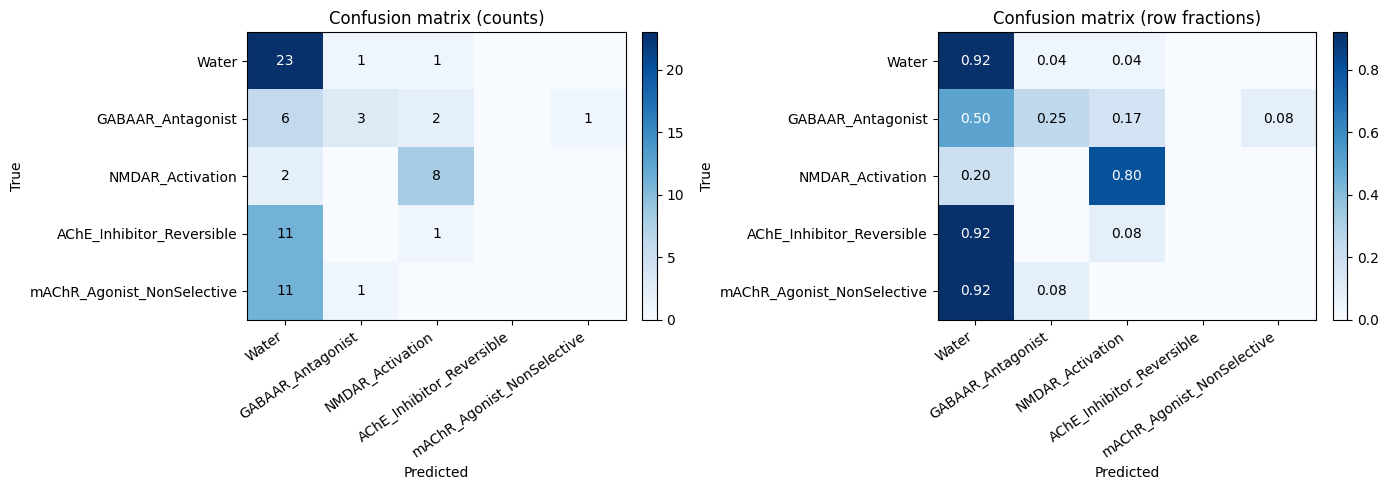


## Holdout report: compound (including control)


,precision,recall,f1-score,support
class,,,,
Control,0.433962,0.920,0.589744,25.0
Bemegride,0.000000,0.000,0.000000,6.0
Bicuculline,0.000000,0.000,0.000000,3.0
Gabazine,0.000000,0.000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.000,0.000000,3.0
Cis-ACPD,0.000000,0.000,0.000000,3.0
N-methyl-D-aspartate,0.000000,0.000,0.000000,4.0
Donepezil,0.000000,0.000,0.000000,4.0
Galantamine,0.000000,0.000,0.000000,4.0


,value
accuracy,0.338028
macro_precision,0.048766
macro_recall,0.080385
macro_f1,0.057199
weighted_precision,0.175339
weighted_recall,0.338028
weighted_f1,0.224991
n_samples,71.000000
roc_auc_ovr_macro,0.597350
average_precision_macro,0.168977


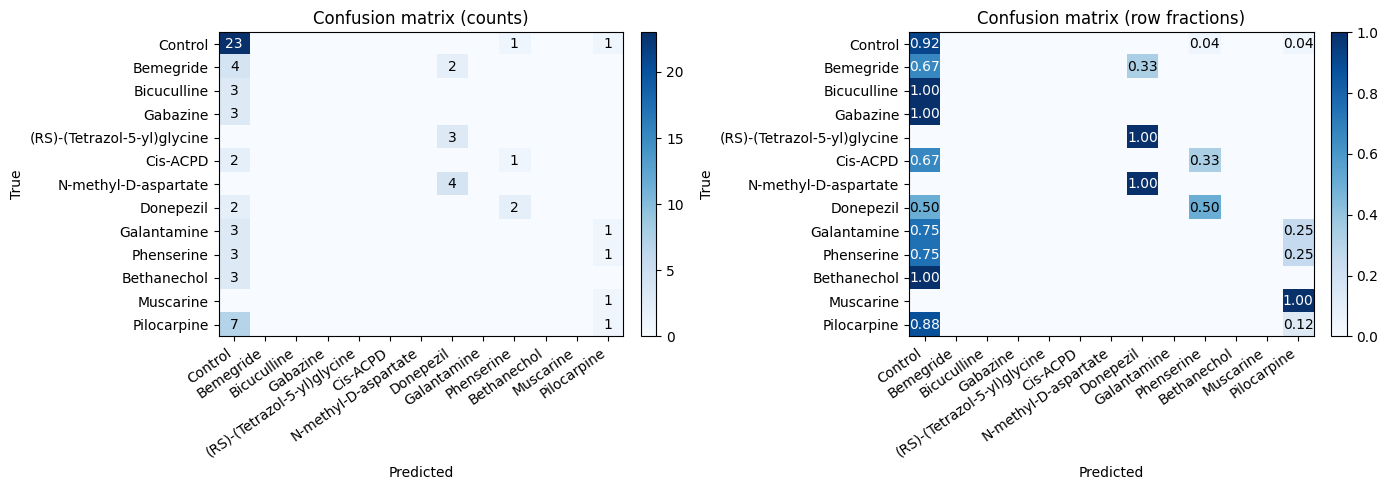


## Holdout report: concentration (including control)


,precision,recall,f1-score,support
class,,,,
control,0.10000,0.08,0.088889,25.0
high,0.26087,0.48,0.338028,25.0
mid,0.00000,0.00,0.000000,21.0


,value
accuracy,0.197183
macro_precision,0.120290
macro_recall,0.186667
macro_f1,0.142306
weighted_precision,0.127067
weighted_recall,0.197183
weighted_f1,0.150323
n_samples,71.000000
roc_auc_ovr_macro,0.413140
average_precision_macro,0.303728


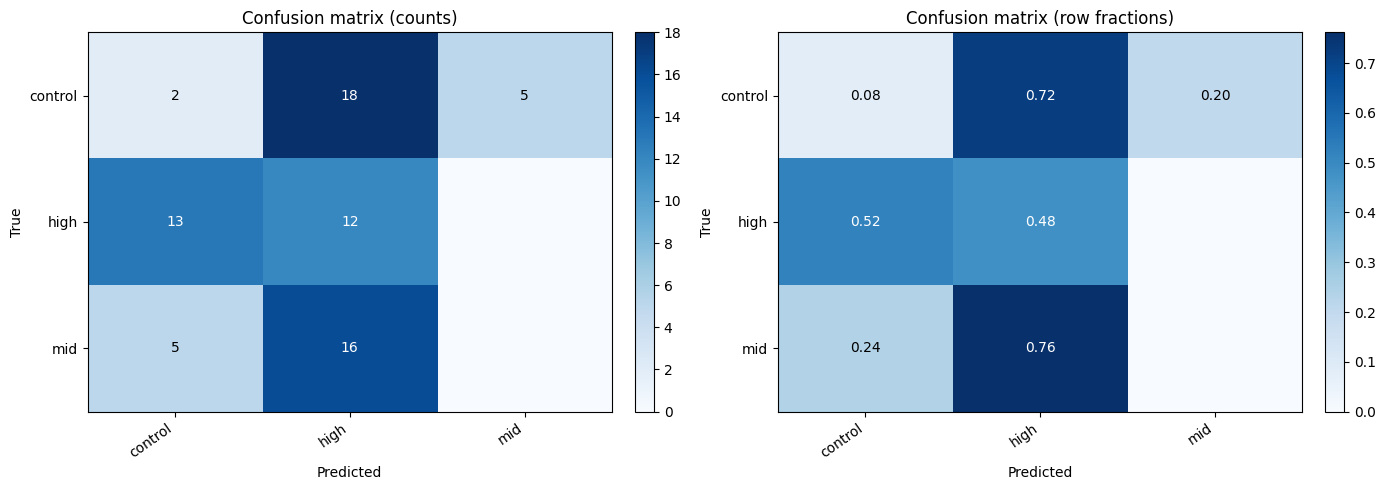


## Holdout report: action (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
GABAAR_Antagonist,0.750000,0.250000,0.375000,12.0
NMDAR_Activation,0.727273,0.800000,0.761905,10.0
AChE_Inhibitor_Reversible,0.333333,0.250000,0.285714,12.0
mAChR_Agonist_NonSelective,0.454545,0.833333,0.588235,12.0


,value
accuracy,0.521739
macro_precision,0.566288
macro_recall,0.533333
macro_f1,0.502714
weighted_precision,0.559289
weighted_recall,0.521739
weighted_f1,0.491444
n_samples,46.000000
roc_auc_ovr_macro,0.820261
average_precision_macro,0.646854


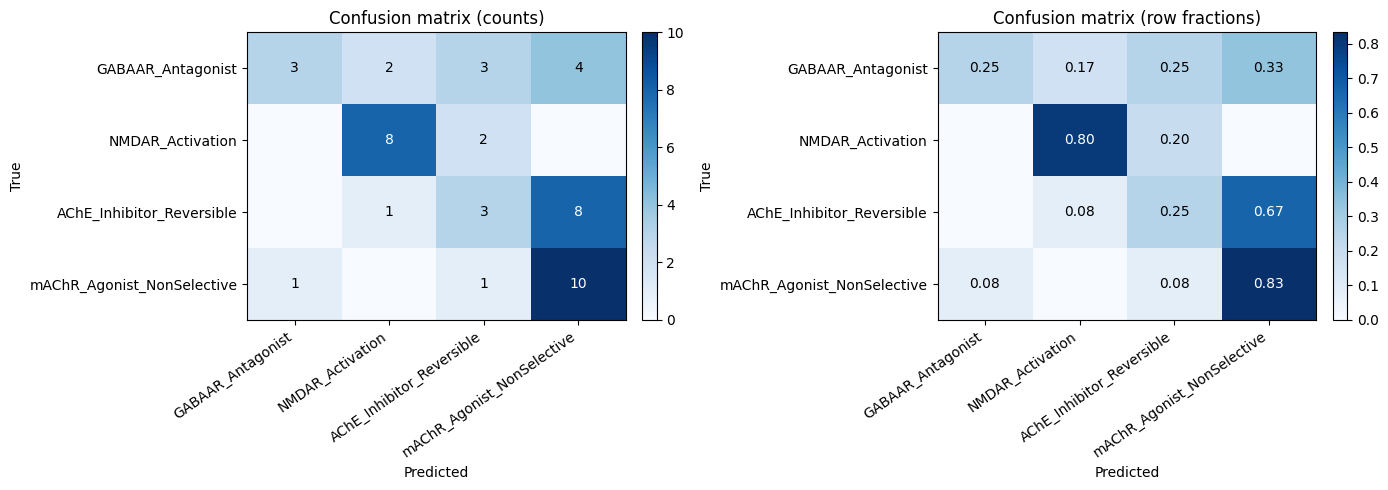


## Holdout report: compound (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
Bemegride,0.000000,0.000,0.000000,6.0
Bicuculline,0.000000,0.000,0.000000,3.0
Gabazine,0.000000,0.000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.000,0.000000,3.0
Cis-ACPD,0.000000,0.000,0.000000,3.0
N-methyl-D-aspartate,0.000000,0.000,0.000000,4.0
Donepezil,0.000000,0.000,0.000000,4.0
Galantamine,0.000000,0.000,0.000000,4.0
Phenserine,0.047619,0.250,0.080000,4.0


,value
accuracy,0.086957
macro_precision,0.021825
macro_recall,0.052083
macro_f1,0.029394
weighted_precision,0.041408
weighted_recall,0.086957
weighted_f1,0.054387
n_samples,46.000000
roc_auc_ovr_macro,0.595170
average_precision_macro,0.193162


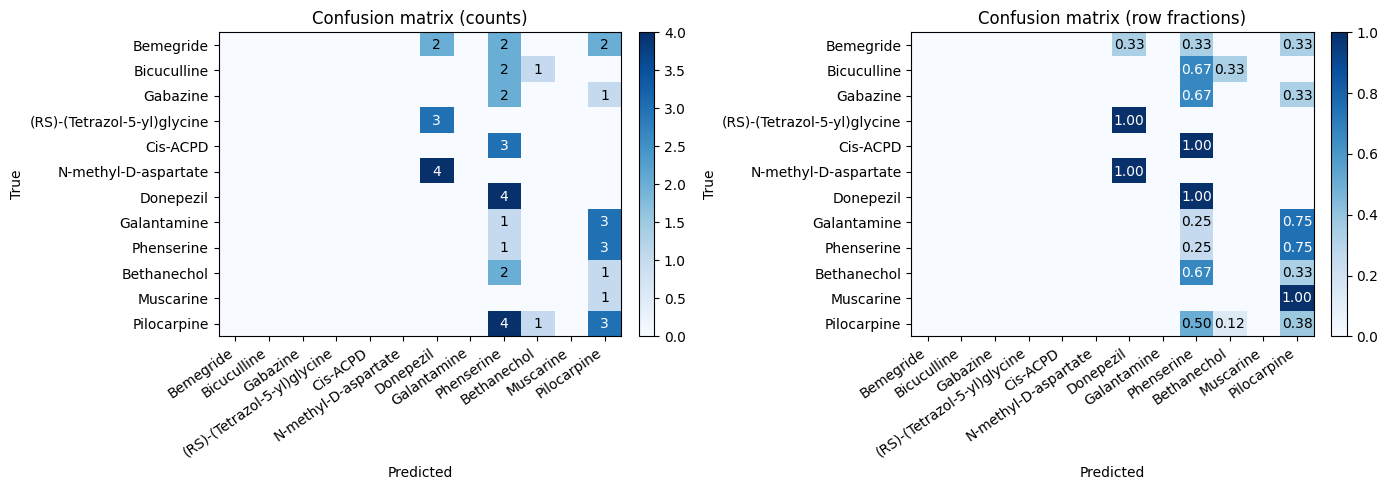


## Holdout report: concentration (excluding control; probabilities renormalized)


,precision,recall,f1-score,support
class,,,,
high,0.466667,0.560000,0.509091,25.0
mid,0.312500,0.238095,0.270270,21.0


,value
accuracy,0.413043
macro_precision,0.389583
macro_recall,0.399048
macro_f1,0.389681
weighted_precision,0.396286
weighted_recall,0.413043
weighted_f1,0.400064
n_samples,46.000000
roc_auc,0.339048
average_precision,0.383393


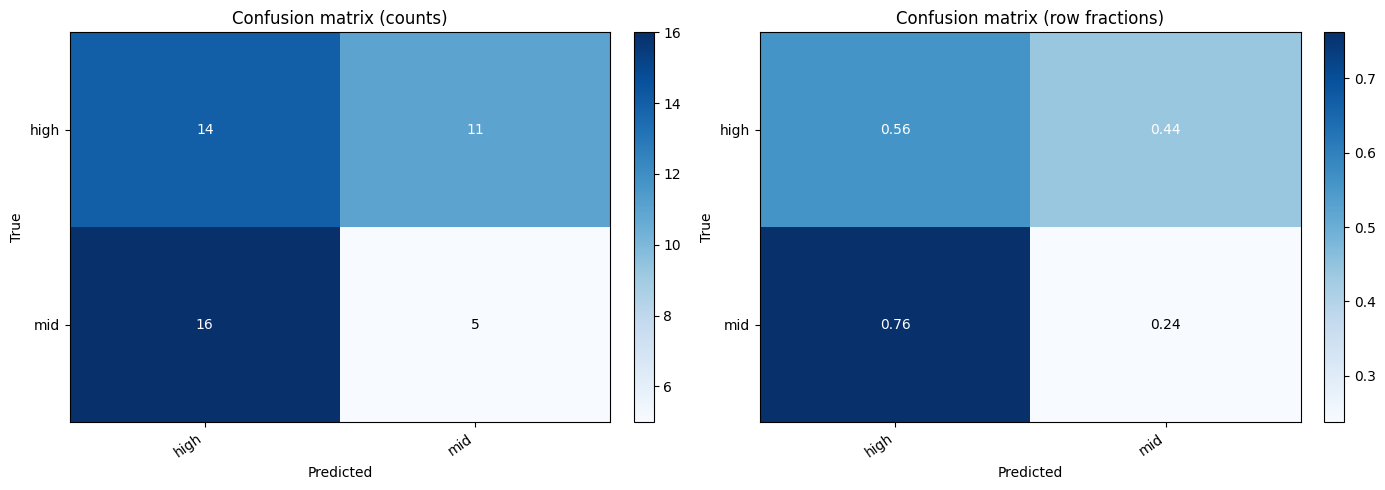

In [5]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

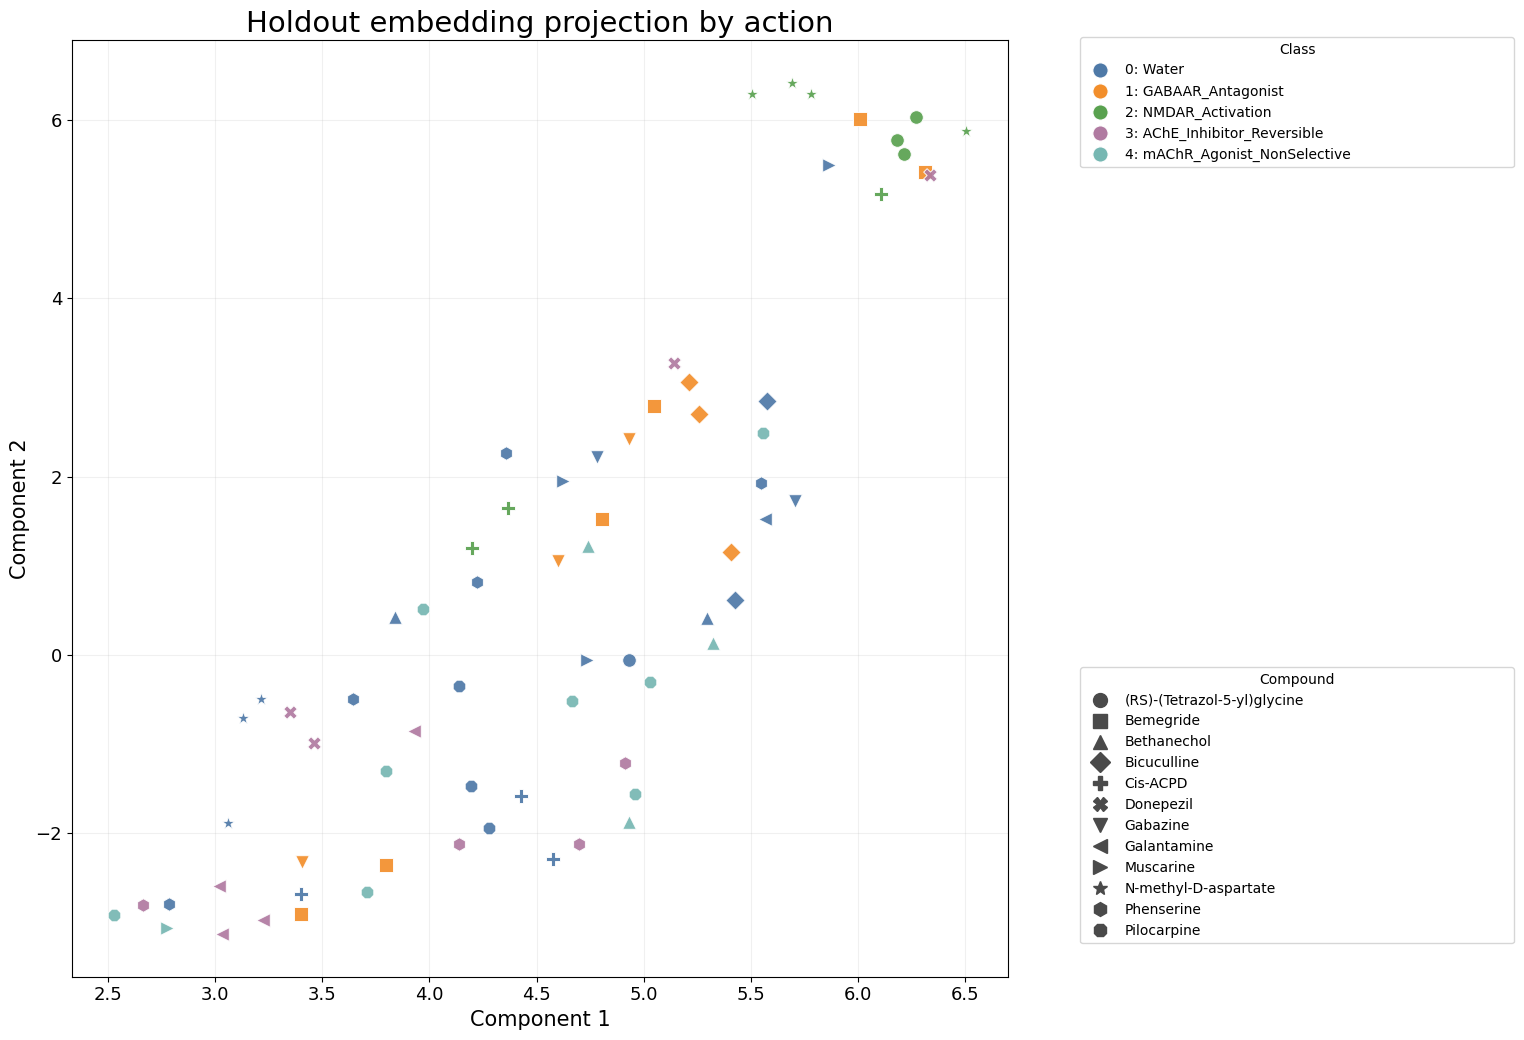

In [6]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'All labeled data embedding projection by action (controls hidden)'}, xlabel='Component 1', ylabel='Component 2'>)

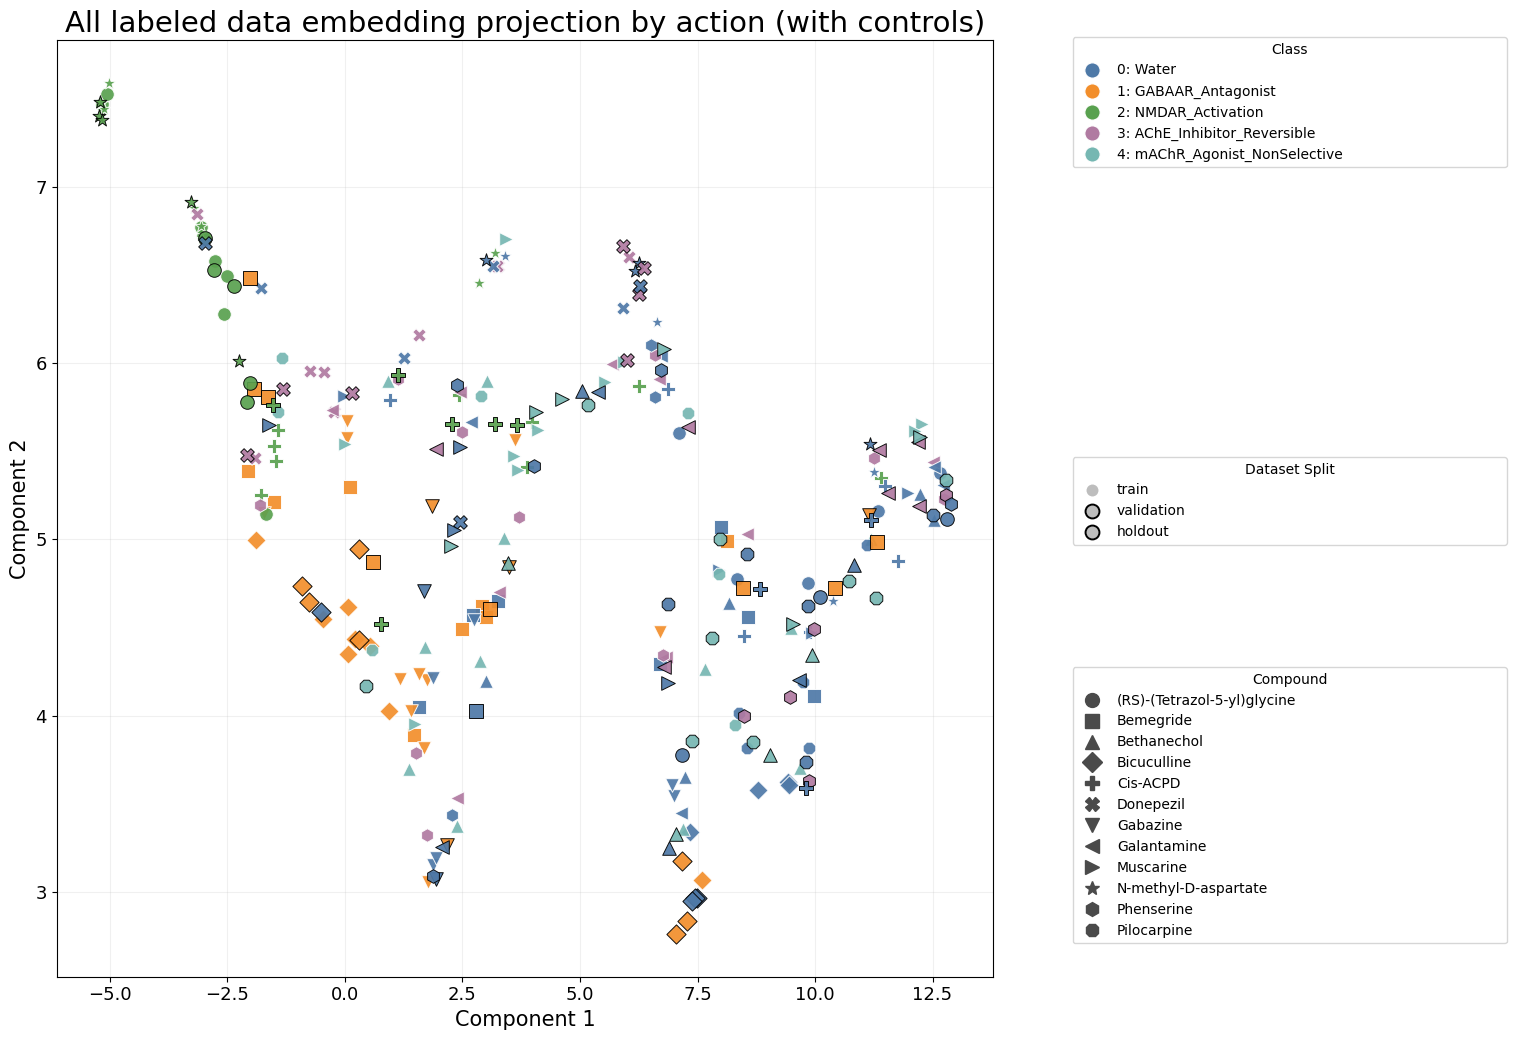

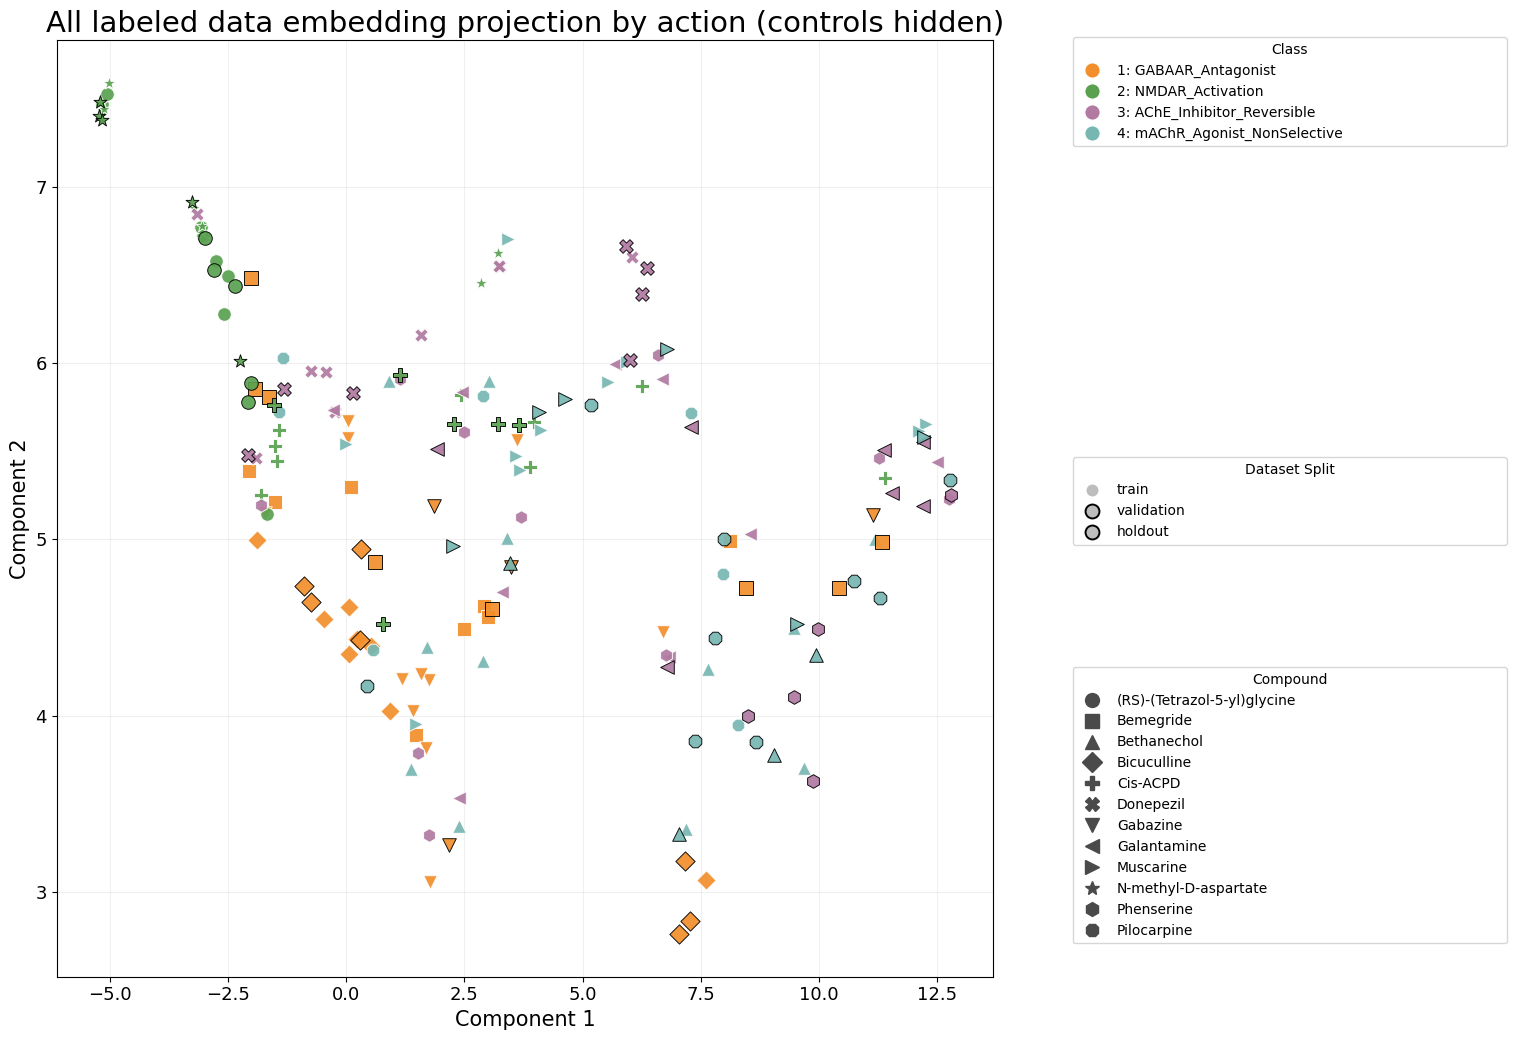

In [7]:
import torch

all_labeled_tensors = torch.cat(
    [
        experiment.splits.X_train_base,
        experiment.splits.X_val,
        experiment.splits.X_holdout,
    ],
    dim=0,
)
all_action_labels = torch.cat(
    [
        experiment.splits.y_train_base,
        torch.as_tensor(experiment.splits.y_val),
        torch.as_tensor(experiment.splits.y_holdout),
    ]
).numpy()
all_labeled_metadata = pd.concat(
    [
        experiment.splits.metadata_train_base.assign(dataset_split="train"),
        experiment.splits.metadata_val.assign(dataset_split="validation"),
        experiment.splits.metadata_holdout.assign(dataset_split="holdout"),
    ],
    ignore_index=True,
)

all_embedding_projection = build_tensor_embedding_2d(
    model.transform(all_labeled_tensors),
    all_action_labels,
    label_map=experiment.label_maps["action"],
    metadata=all_labeled_metadata,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action (with controls)",
    marker_column="compound",
    edge_color_column="dataset_split",
    edge_color_map={"train": "white", "validation": "black", "holdout": "black"},
    display_control=True,
)
plot_tensor_embedding_2d(
    all_embedding_projection,
    title="All labeled data embedding projection by action (controls hidden)",
    marker_column="compound",
    edge_color_column="dataset_split",
    edge_color_map={"train": "white", "validation": "black", "holdout": "black"},
    display_control=False,
)

In [8]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "unlabeled_dataset_path": unlabeled_dataset_path,
    "pretraining_config_path": pretraining_config_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "binary_loss_plot_dir": binary_loss_plot_dir,
    "fine_tune_loss_plot_dir": fine_tune_loss_plot_dir,
    "freeze_backbone": False,
    "hot_start": True,
    "run_binary_hot_start": run_binary_hot_start,
    "binary_pretraining_epochs": binary_pretraining_epochs,
    "binary_learning_rate": binary_learning_rate,
    "binary_weight_decay": binary_weight_decay,
    "binary_class_weighting": binary_class_weighting,
    "binary_pretraining_excluded_holdout_count": None if binary_pretraining_data is None else binary_pretraining_data.excluded_holdout_count,
    "binary_pretraining_label_map": None if binary_pretraining_data is None else binary_pretraining_data.label_map,
    "binary_pretraining_train_count": None if binary_pretraining_data is None else binary_pretraining_data.train_count,
    "binary_pretraining_val_count": None if binary_pretraining_data is None else binary_pretraining_data.val_count,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    if binary_pretraining_history is not None:
        binary_pretraining_history.to_csv(experiment_output_dir / "binary_pretraining_history.csv", index=False)
    experiment_artifacts
